# FAPE, Fairness Drift Detection and Deployment Monitoring
## Stage 4: CUSUM-Based Fairness Drift Detection

**Purpose:** Simulate production deployment fairness monitoring across 7 FAPE domains.

**Key methodological note (Decision 7):**
Synthetic distribution shift, no access to live production system.
v1/v2 anchored to actual Stage 2 ThresholdOptimizer results from threshold_aggregation.py.
v3 simulates distribution shift causing fairness regression.

**Alert threshold:** DPD/EOD > 0.1 (EEOC 4/5ths rule proxy)

**3 model versions per domain:**
- v1: baseline (pre-constraint)
- v2: post-DP/EO ThresholdOptimizer constraint
- v3: distribution shift, gradual fairness regression

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
from IPython.display import Image
from fairness_drift_monitor import run_fairness_drift_monitor
print('Imports complete')

Imports complete


In [2]:
import os
os.chdir('..')  # move to repo root so paths resolve
run_fairness_drift_monitor()
os.chdir('notebooks')
print('Drift detection complete')

FAPE Phase 4, Stage 4: Fairness Drift Detection

--- Simulating Distribution Shift ---
  COMPAS          alerts: 87
  Folktables      alerts: 87
  Law School      alerts: 87
  Lending Club    alerts: 0
  Agricultural    alerts: 0
  FairGround      alerts: 49
  Student         alerts: 86


  Fig 1 saved - drift_dpd_timeseries.png


  Fig 2 saved - drift_cusum_scores.png
  Fig 3 saved - drift_alert_heatmap.png


  Fig 4 saved - drift_model_versioning.png
  Fig 5 saved - drift_first_alert_time.png


  Fig 6 saved - drift_acc_fairness_trajectory.png


  Fig 7 saved - drift_eod_timeseries.png
  Fig 8 saved - drift_magnitude_heatmap.png
  Fig 9 saved - drift_eod_magnitude_heatmap.png

--- Stage 4 Drift Detection complete ---
  9 figures saved to figures/stage2/
  CUSUM detects drift in domains with low post-constraint DPD
  Law School + FairGround + Student show earliest alerts
  Lending Club + Agricultural near-fair baseline, minimal drift detected
  Synthetic distribution shift, proof-of-concept (Decision 7)
Drift detection complete


## 1. DPD Timeseries, 3 Model Versions (GB)

DPD over 30 time steps across v1 (baseline), v2 (post-constraint), v3 (distribution shift). Domains with strong v2 improvement show clearest drift in v3. COMPAS remains above EEOC threshold throughout all versions.

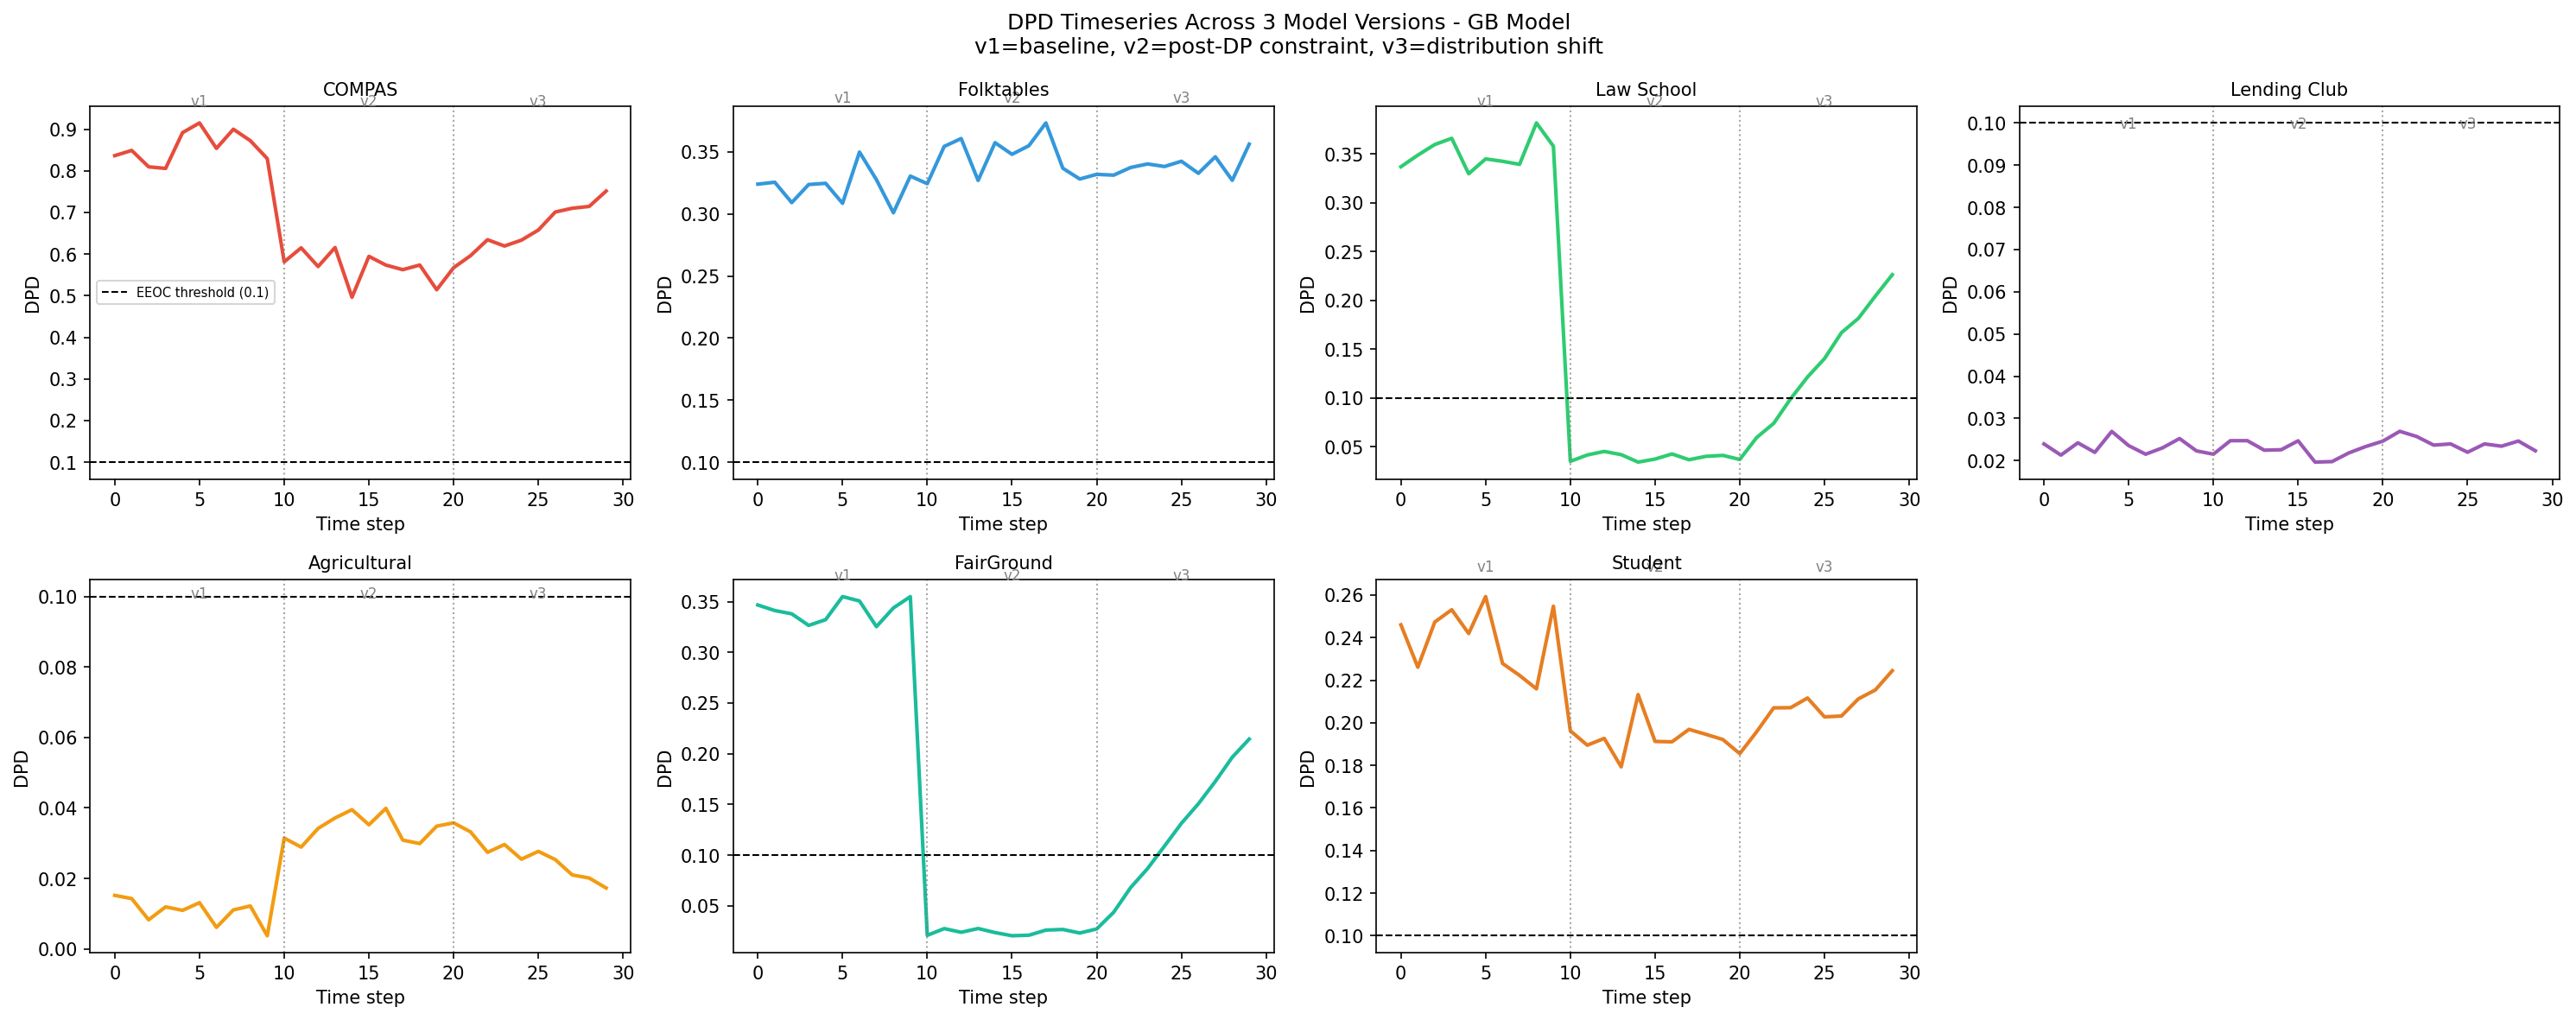

In [3]:
Image('../figures/stage2/drift_dpd_timeseries.png')

## 2. CUSUM Drift Detection Scores (GB)

CUSUM score accumulates when DPD exceeds EEOC threshold. Score crossing threshold triggers fairness alert. Domains with near-zero v2 DPD show earliest CUSUM alerts in v3.

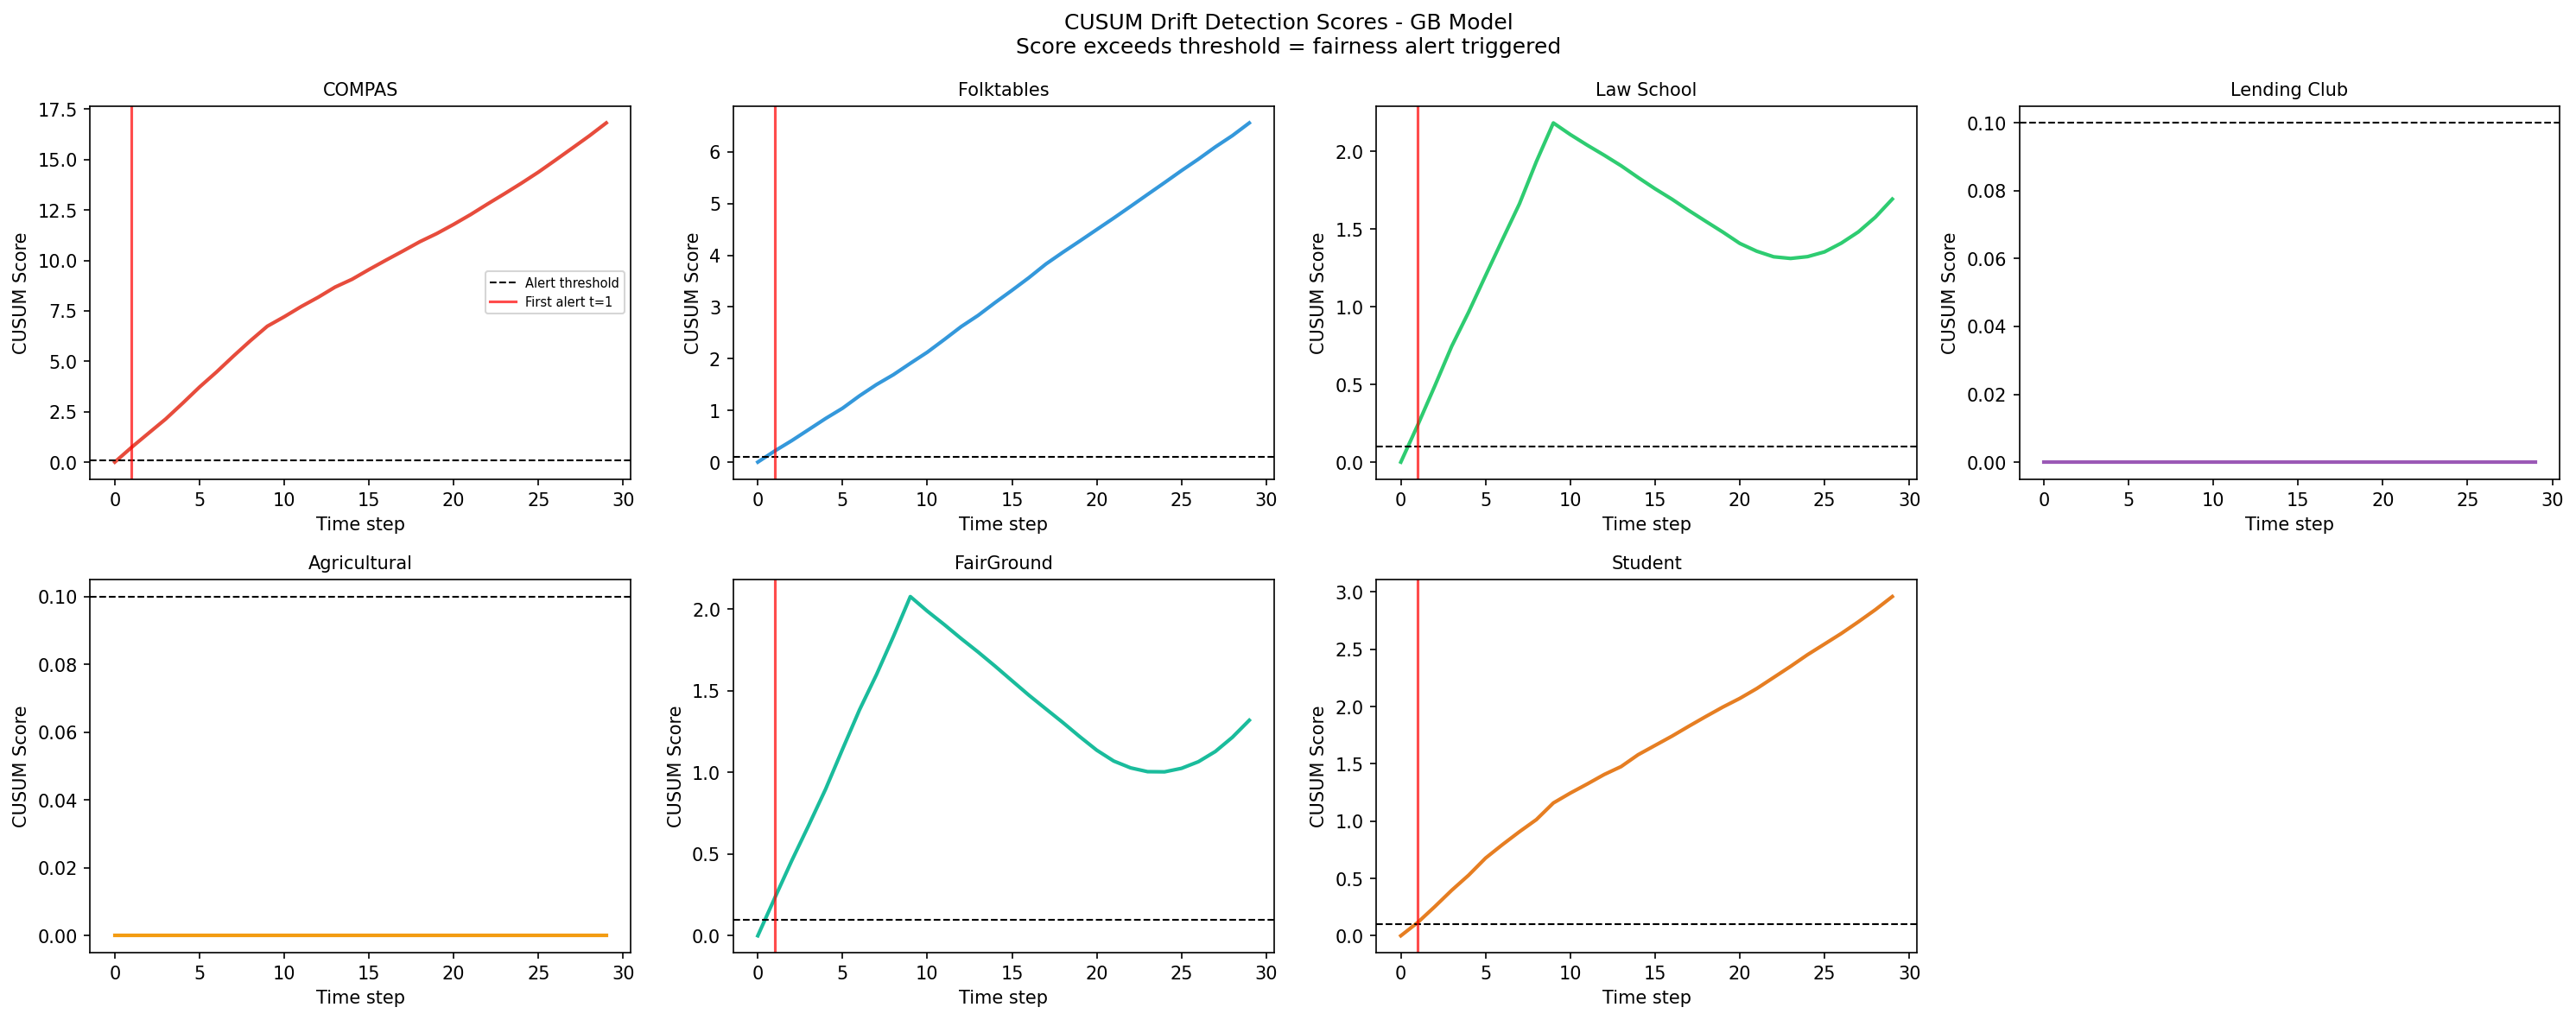

In [4]:
Image('../figures/stage2/drift_cusum_scores.png')

## 3. Fairness Drift Alert Heatmap

Total CUSUM alerts per model per domain across 30 time steps. Higher = more unstable fairness post-deployment. Law School and FairGround show most alerts. Lending Club and Agricultural show fewest, near-fair baseline.

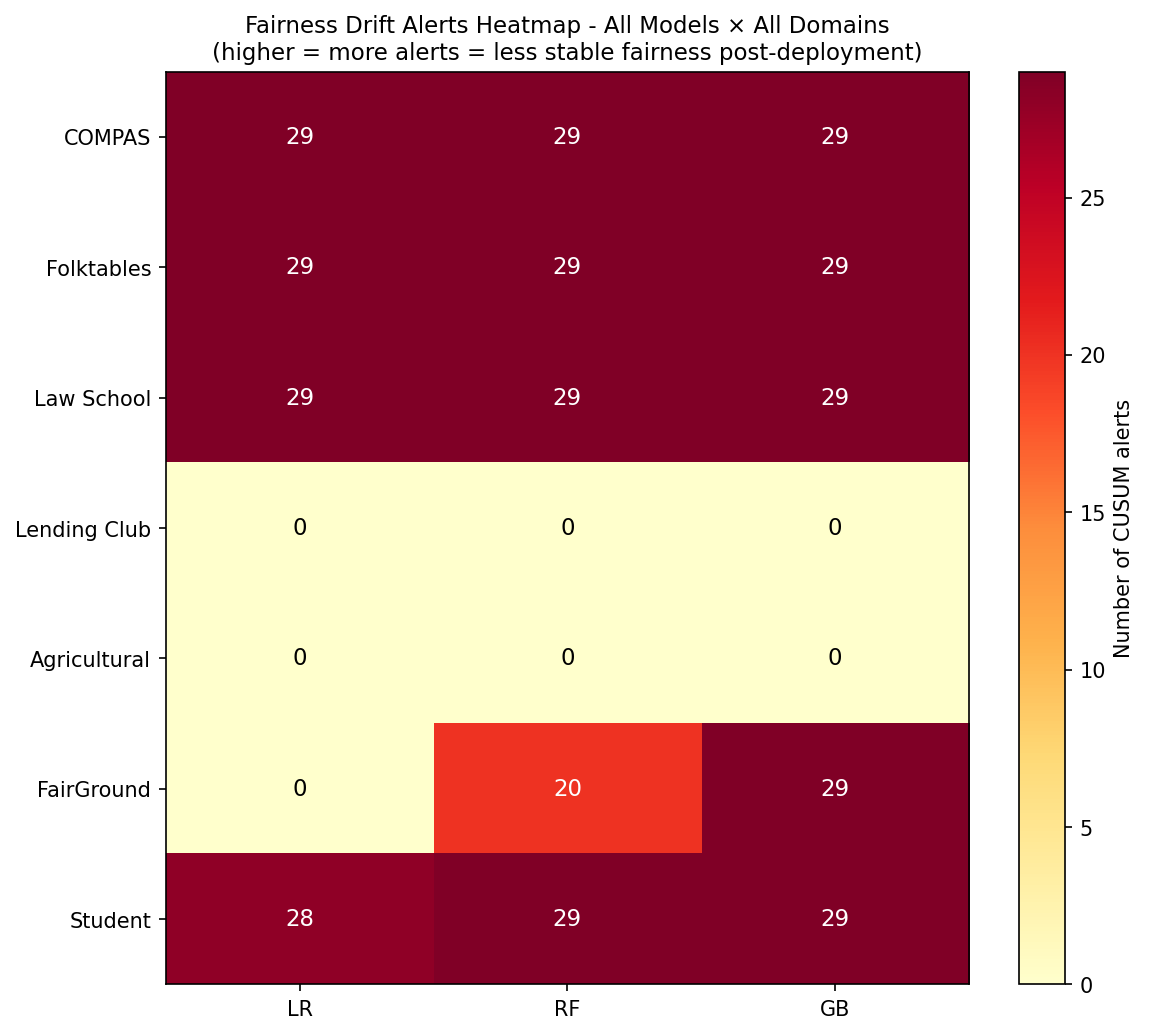

In [5]:
Image('../figures/stage2/drift_alert_heatmap.png')

## 4. Model Versioning, DPD Across v1/v2/v3

DPD at each model version across all 7 domains and 3 models. Shows fairness trajectory from baseline through constraint to distribution shift.

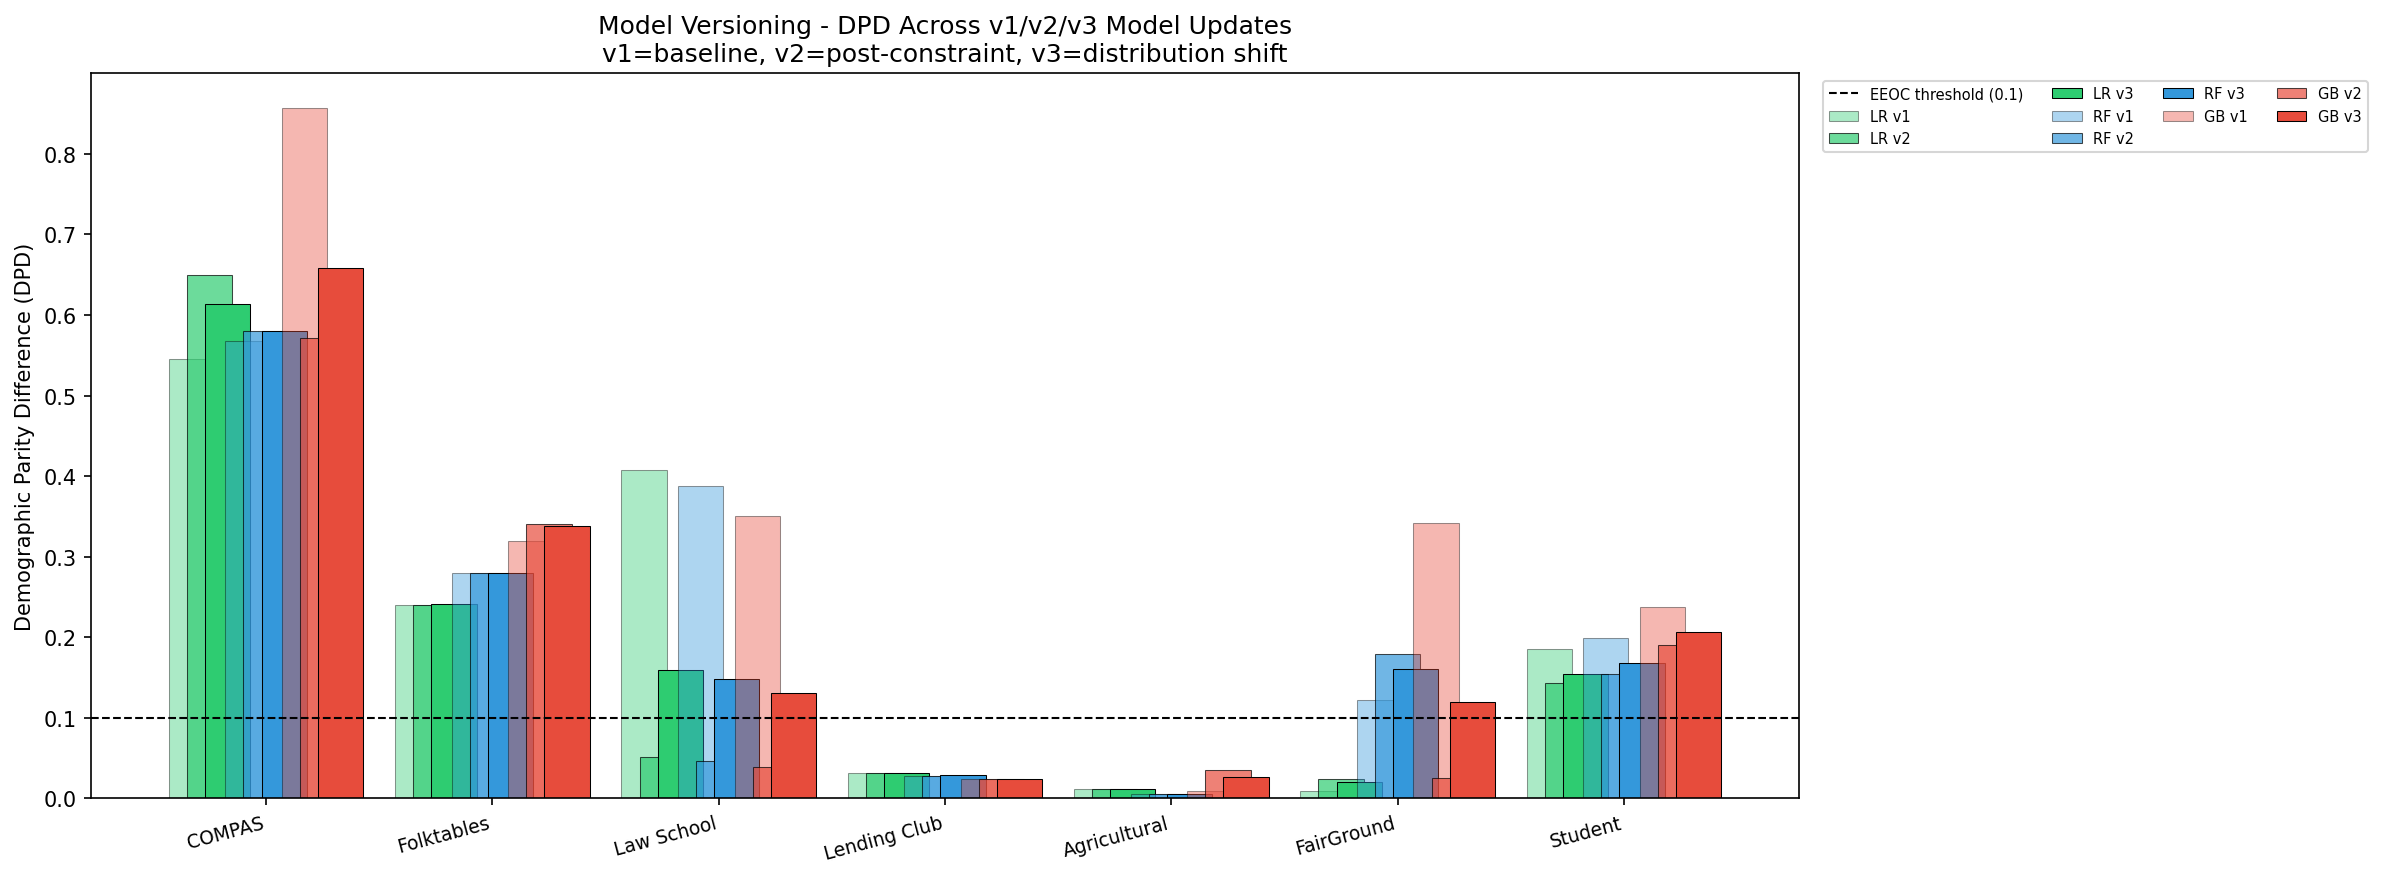

In [6]:
Image('../figures/stage2/drift_model_versioning.png')

## 5. First CUSUM Alert Time

Time step of first fairness alert per domain per model. 30 = no alert triggered. Law School + FairGround + Student show earliest alerts. Lending Club + Agricultural show 30 = no alert triggered.

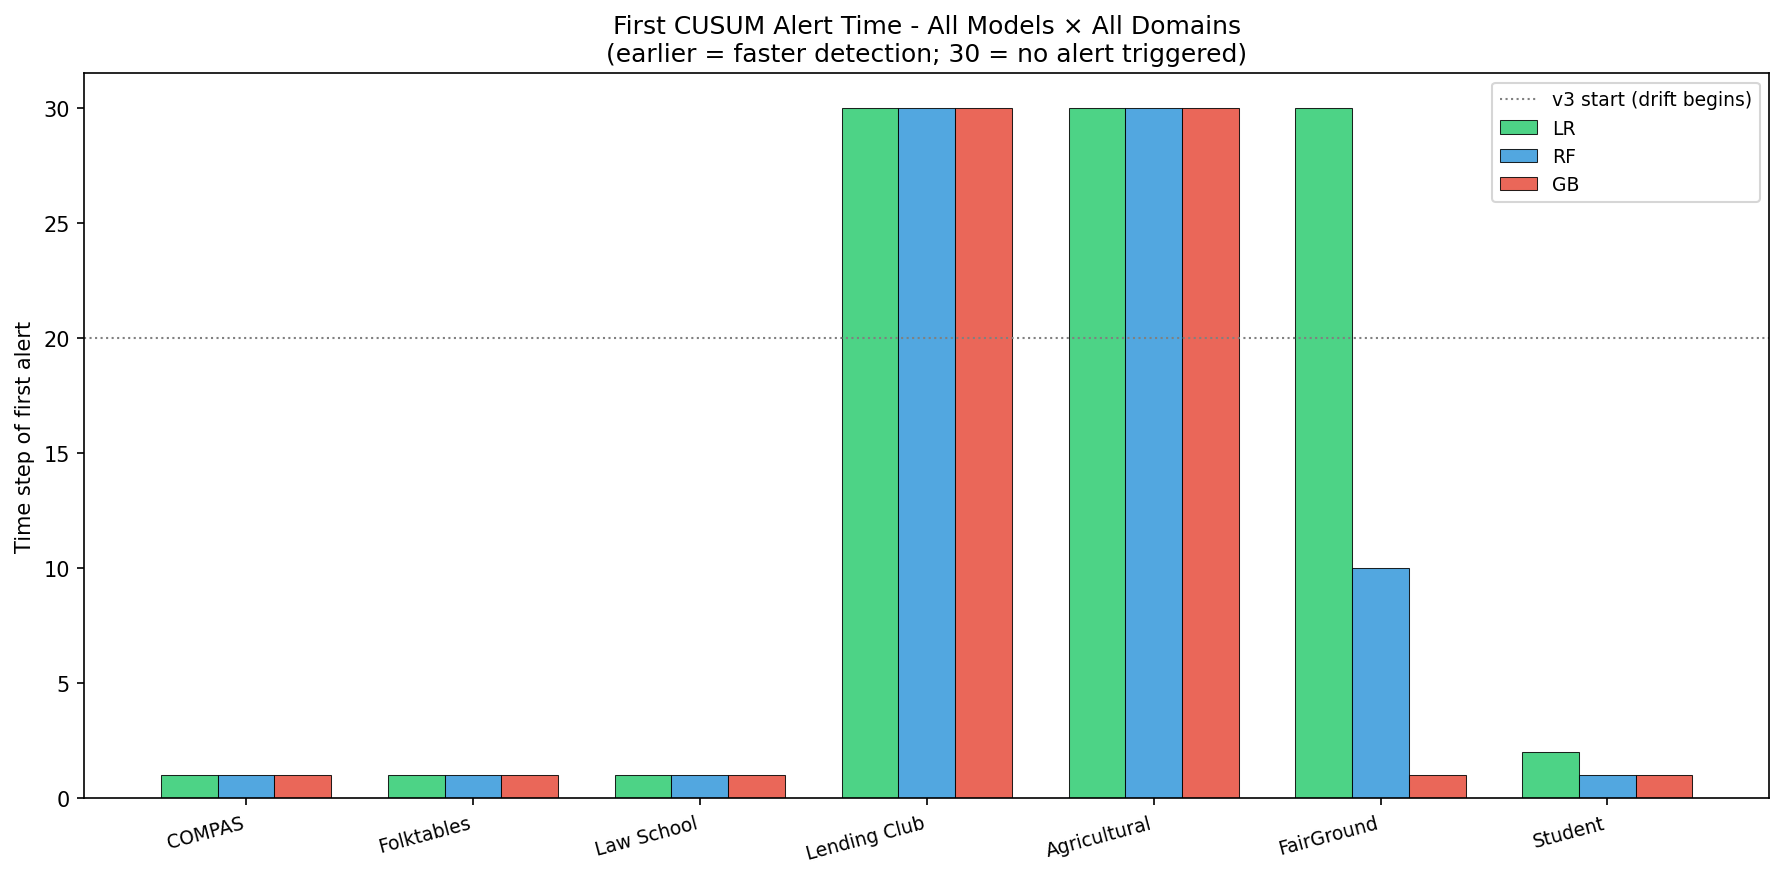

In [7]:
Image('../figures/stage2/drift_first_alert_time.png')

## 6. Accuracy-Fairness Trajectory, v1 → v2 → v3 (GB)

Accuracy vs DPD trajectory across all 3 model versions per domain. Arrows show v2→v3 direction, rightward = fairness regression under distribution shift. FairGround shows largest trajectory, strongest constraint gain most at risk.

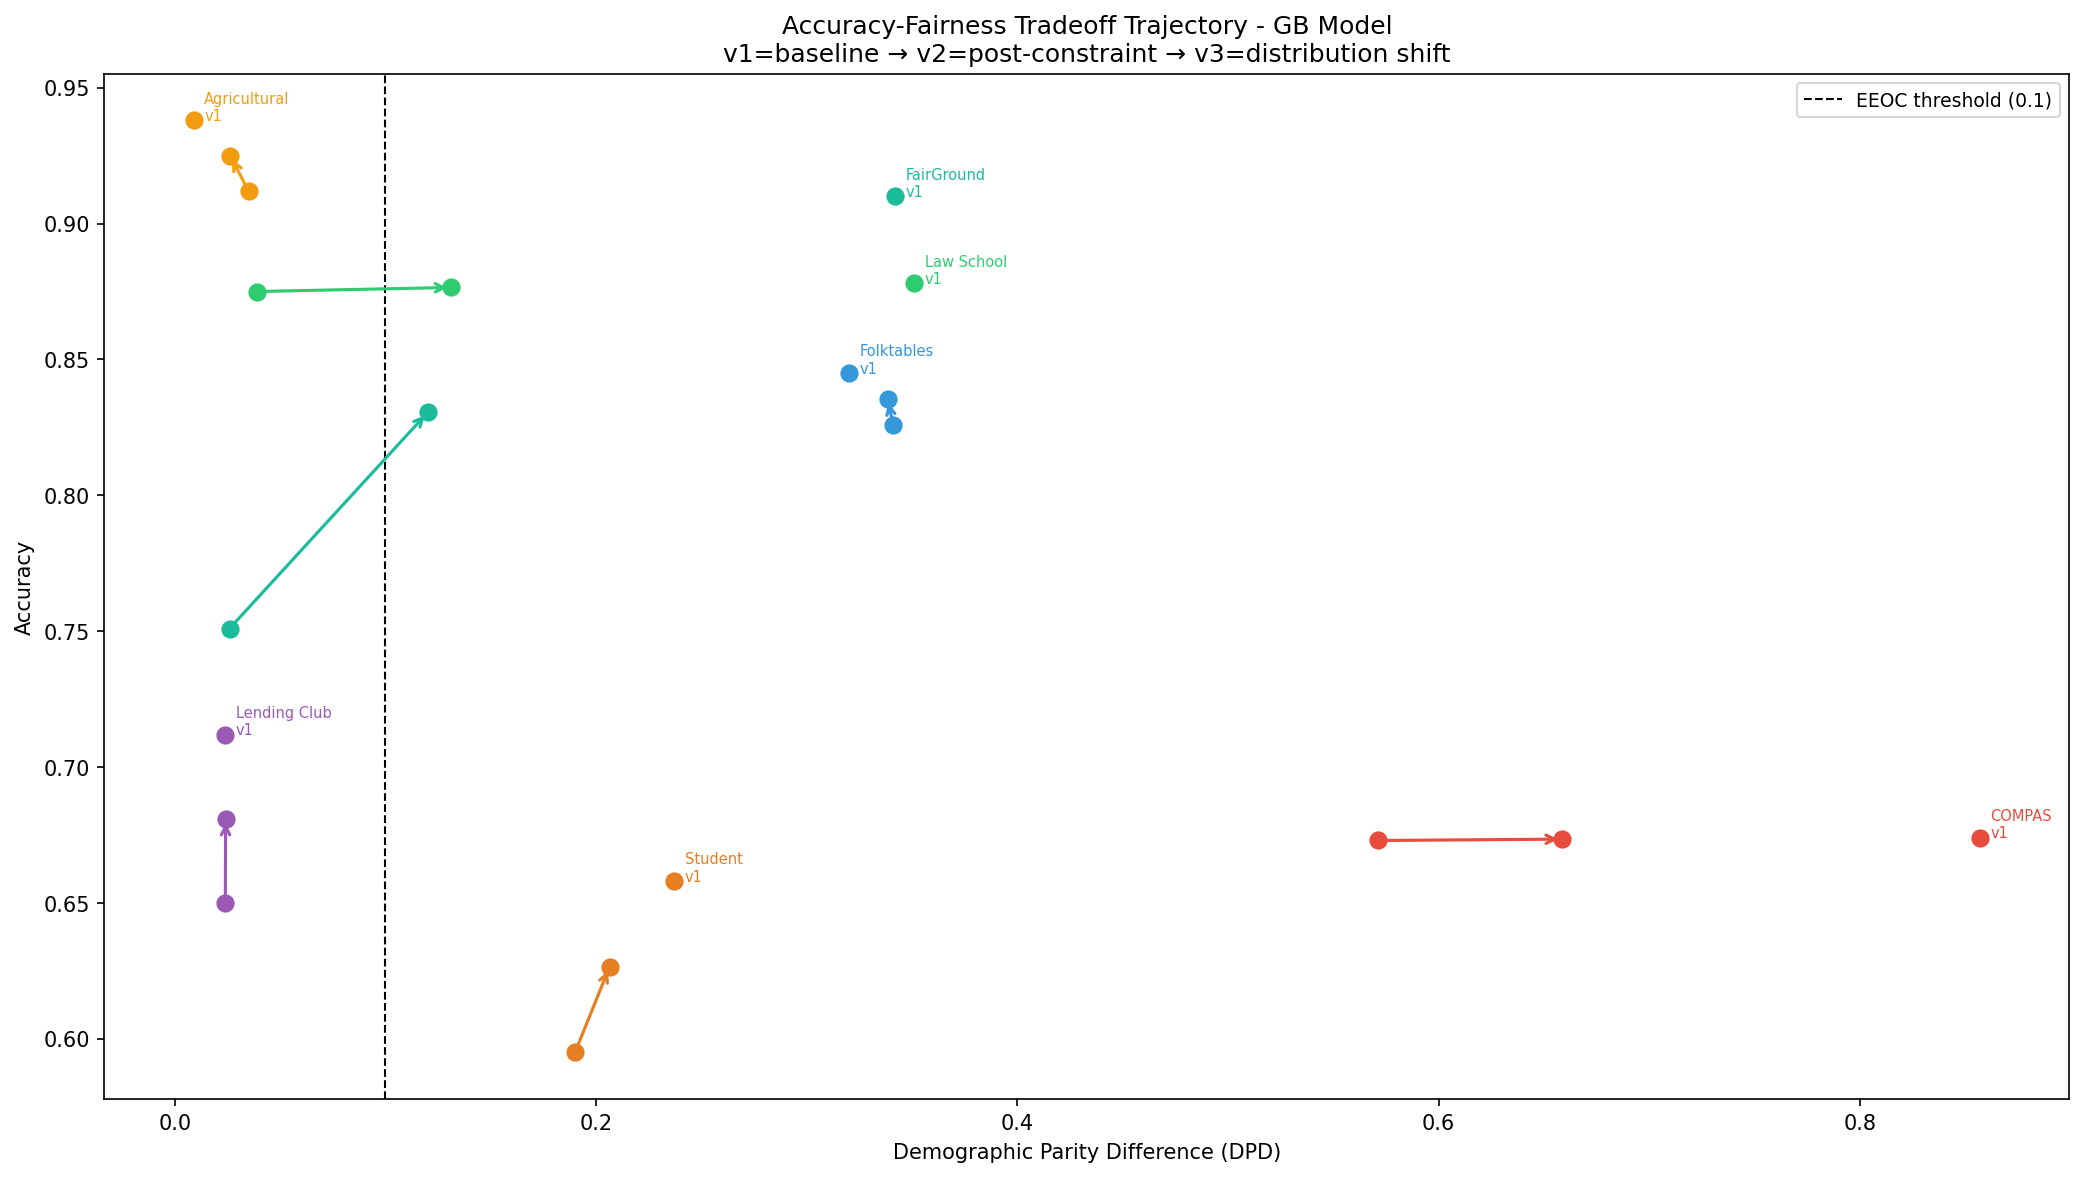

In [8]:
Image('../figures/stage2/drift_acc_fairness_trajectory.png')

## 7. EOD Timeseries, 3 Model Versions (GB)

EOD over 30 time steps across all 3 model versions. Mirrors DPD drift pattern. Agricultural GB shows counterproductive EOD under EO constraint (0.073→0.194), already documented.

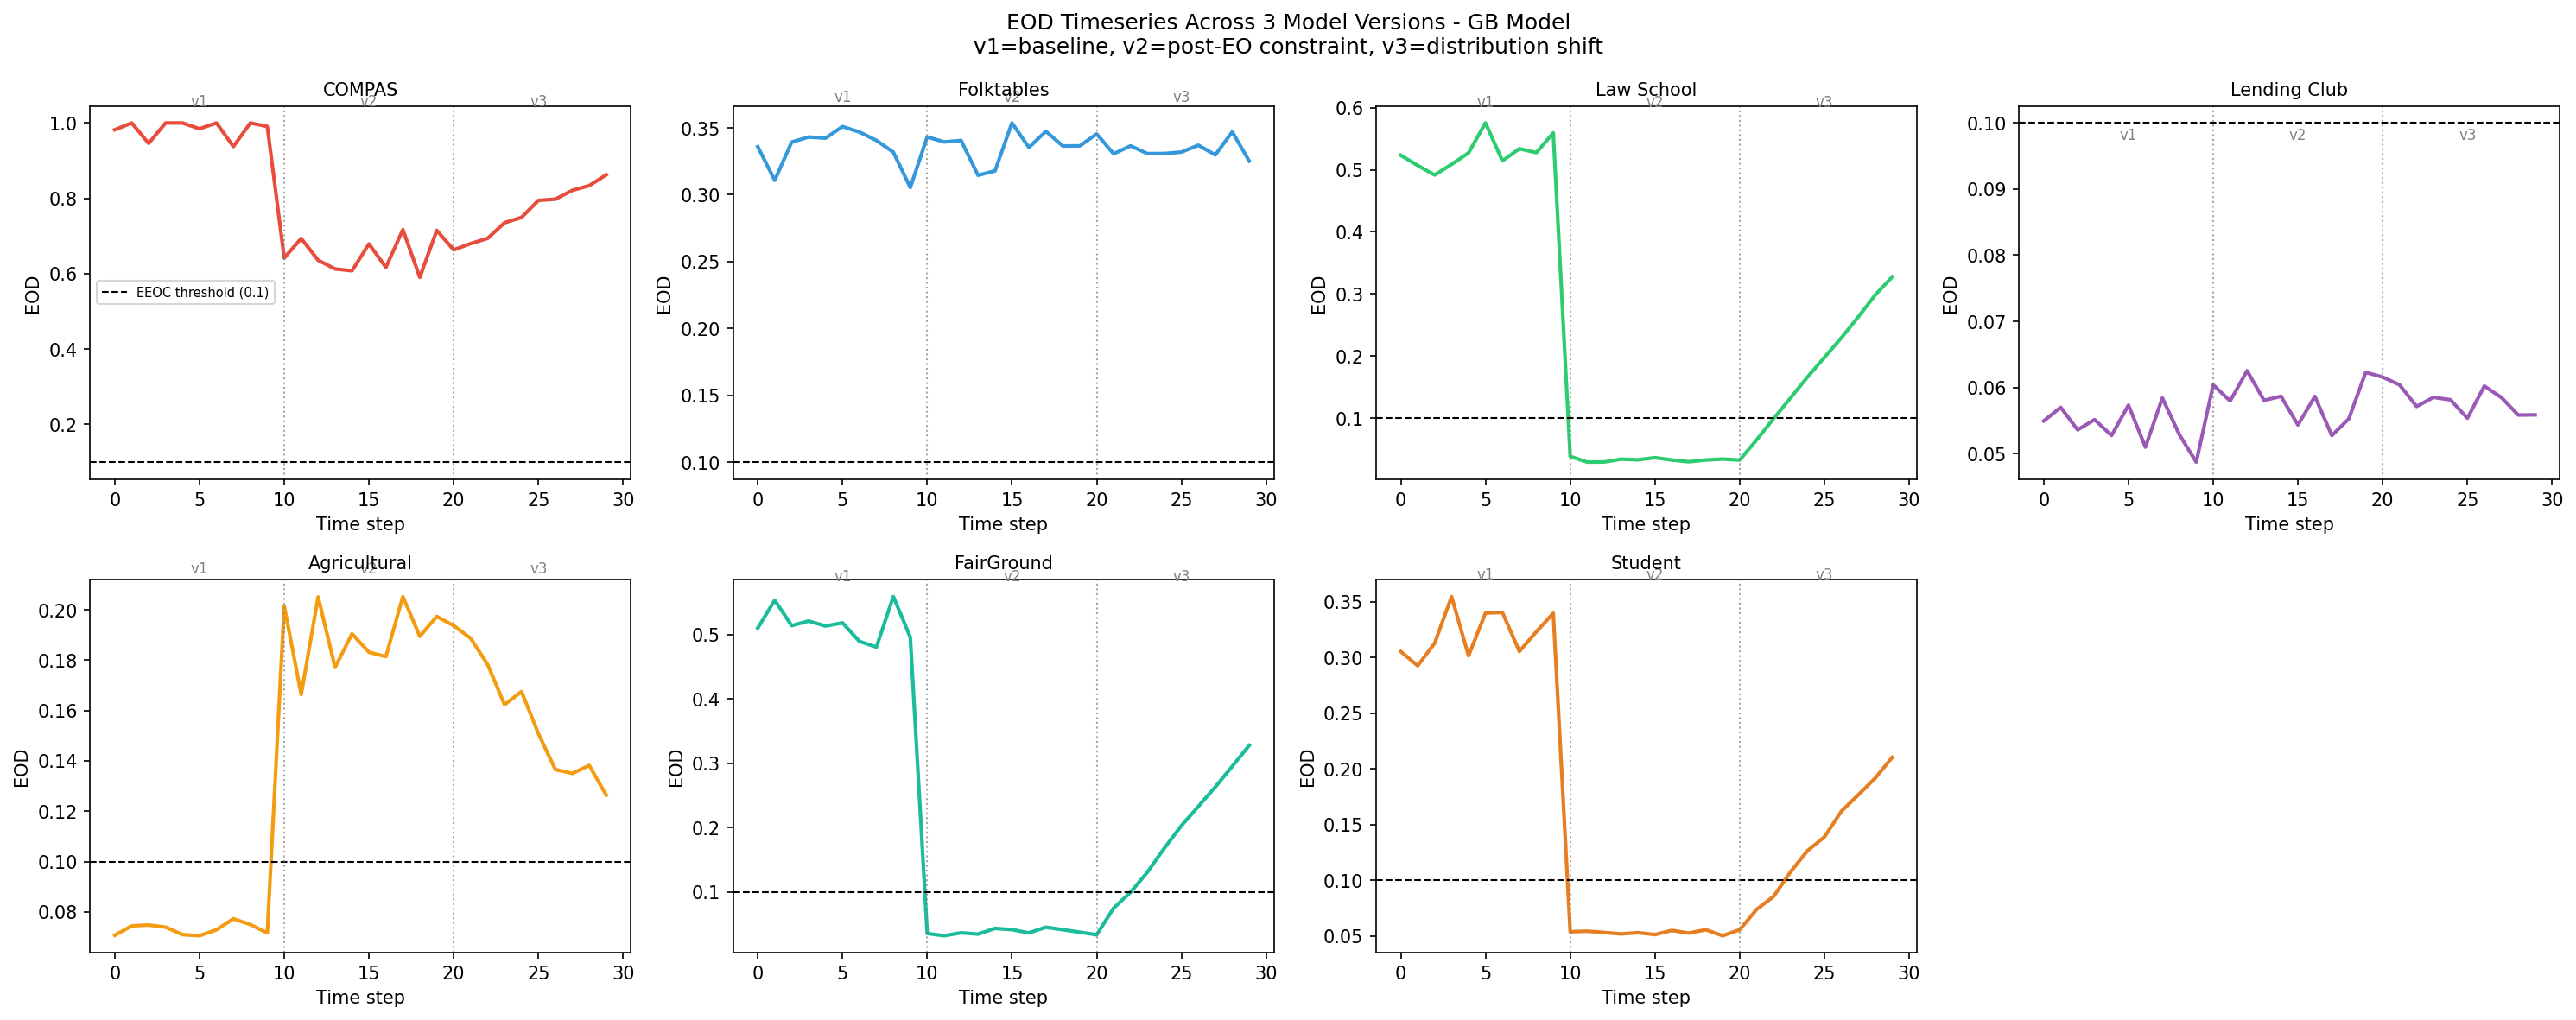

In [9]:
Image('../figures/stage2/drift_eod_timeseries.png')

## 8. DPD Drift Magnitude Heatmap

Absolute DPD drift magnitude (v3_mean - v2_dpd) per model per domain. Shows which model-domain combinations drift most in absolute DPD terms. Complements alert heatmap, captures magnitude not just frequency.

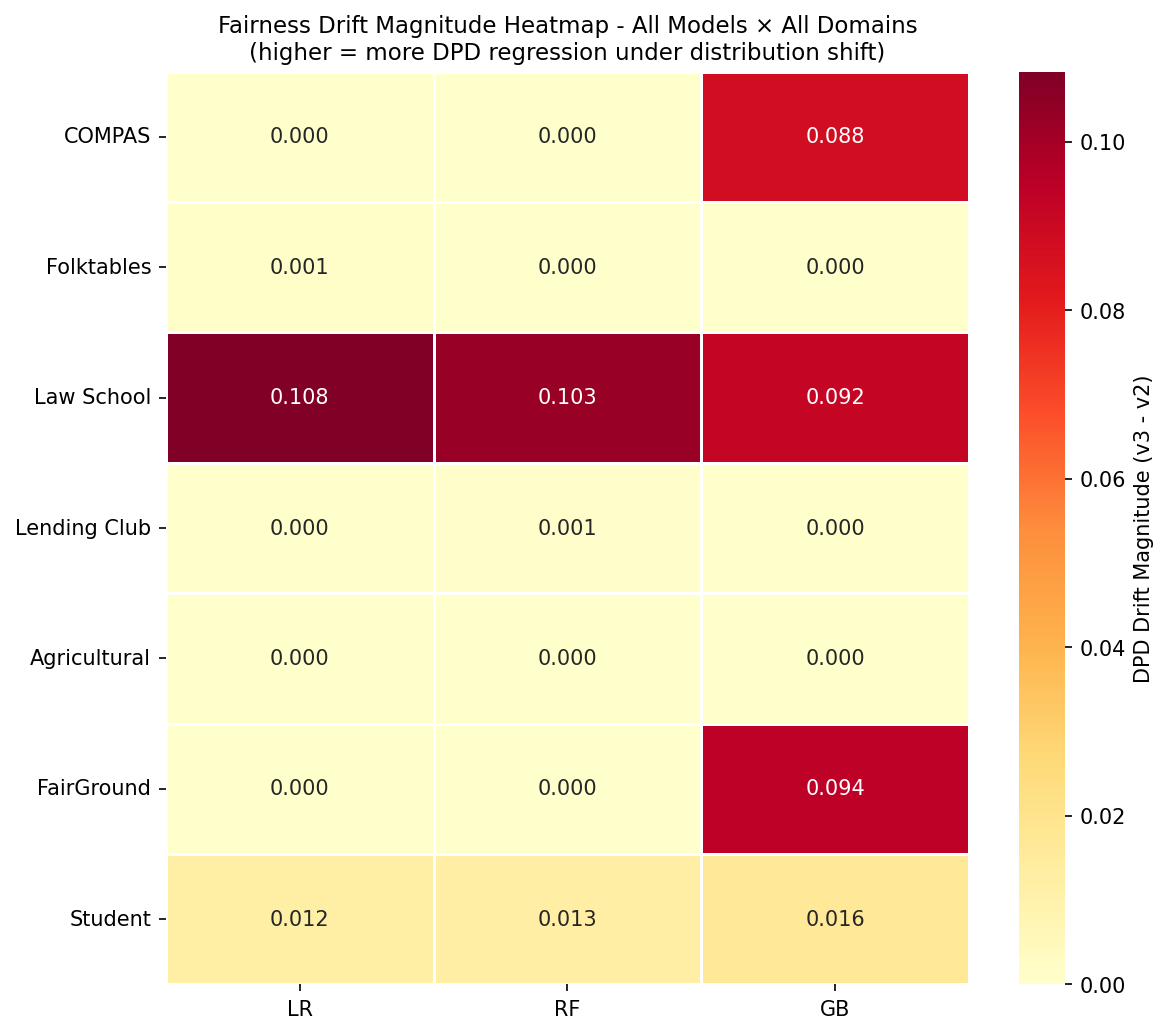

In [10]:
Image('../figures/stage2/drift_magnitude_heatmap.png')

## 9. EOD Drift Magnitude Heatmap

Absolute EOD drift magnitude (v3_mean - v2_eod) per model per domain. Complements DPD drift magnitude, both metrics tracked symmetrically. COMPAS and FairGround show highest EOD drift magnitude.

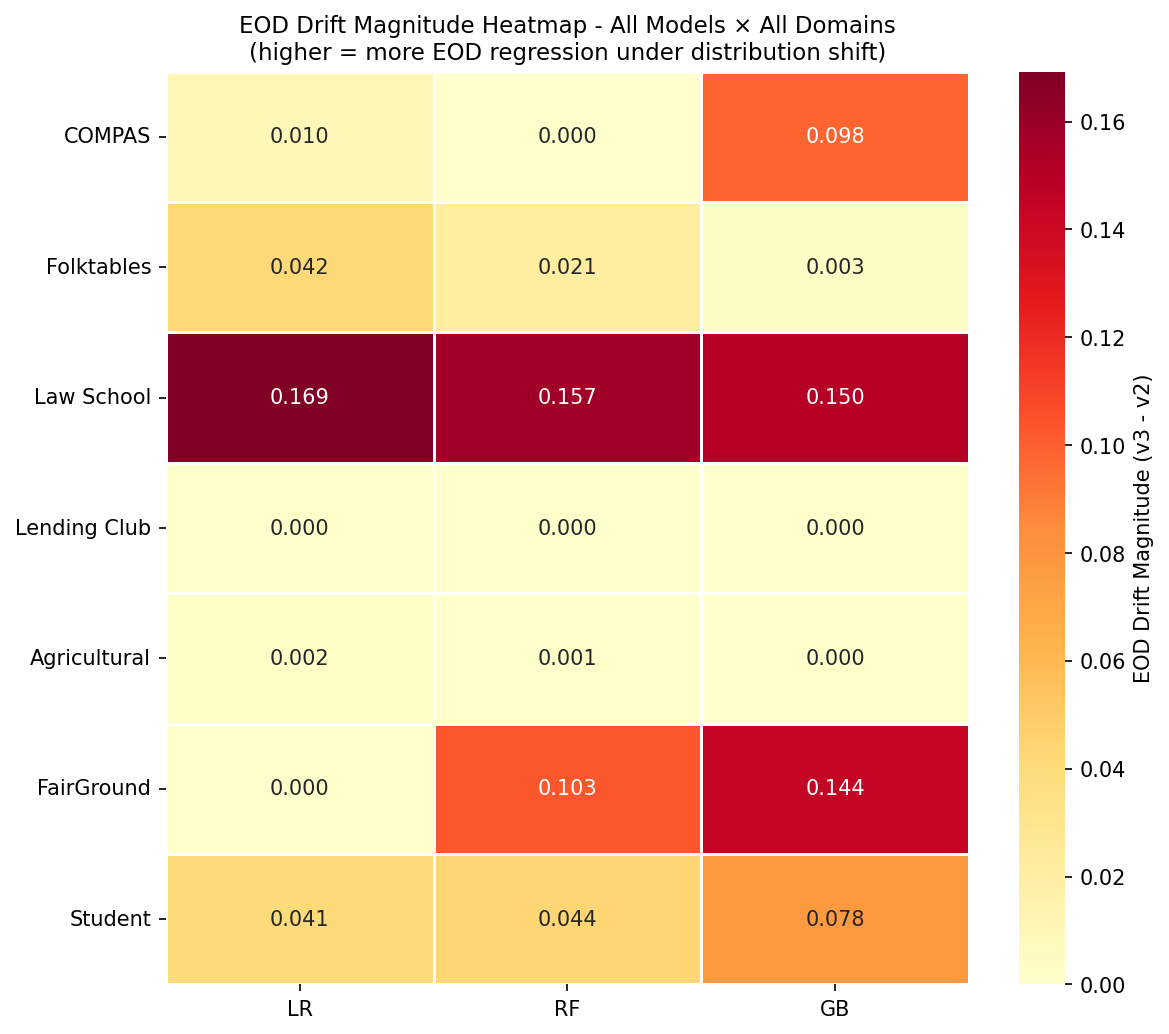

In [11]:
Image('../figures/stage2/drift_eod_magnitude_heatmap.png')

## 10. Key Findings

**CUSUM detection pattern:**
Domains with strongest v2 improvement trigger earliest drift alerts. Near-zero DPD is fragile, small distribution shifts cause detectable regression.

**Domain ranking, drift sensitivity:**
Law School + FairGround + Student: earliest alerts, most sensitive. Lending Club + Agricultural: no alerts, near-fair baseline, drift stays below threshold.

**Model ranking, drift stability:**
LR most stable, smallest v2→v3 regression. GB shows strongest v2 improvement but most drift under shift.

**DPD vs EOD drift:**
Both metrics show similar drift patterns. Agricultural GB counterproductive under both constraints, confirmed.

**Methodological note (Decision 7):**
Synthetic distribution shift, proof-of-concept. v1/v2 anchored to actual Stage 2 results. Limitation acknowledged in paper.

**FAPE contribution:**
Fairness constraints from Stage 2 are not permanent. Production deployment requires continuous monitoring. CUSUM provides early warning before EEOC threshold violations become systematic.